In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def rmse(sample, target):
    return np.sqrt(np.mean((sample - target) ** 2))

In [21]:
path = 'output/steps_50'

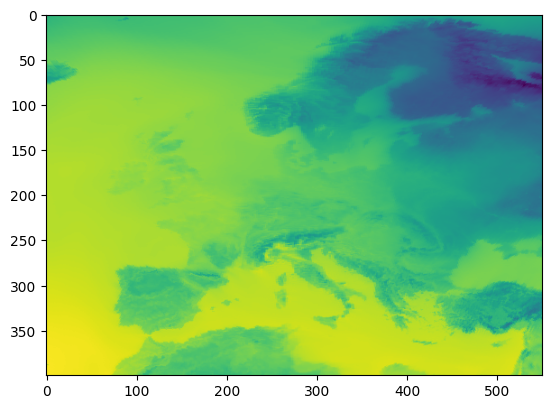

In [22]:
target = torch.load(f'{path}/example_target_0.pt')
target = target.cpu().detach().numpy().reshape(400, 550, 2)
plt.imshow(np.flipud(target[:, :, 1]))
plt.show()

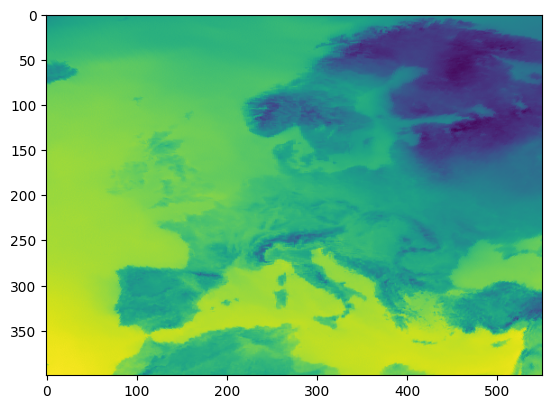

In [33]:
path = 'output/steps_50'
sample = torch.load(f'{path}/example_ens_members_0_0.pt')
sample = sample.cpu().detach().numpy().reshape(400, 550, 2)
plt.imshow(np.flipud(sample[:, :, 1]))
plt.show()

In [29]:
ensemble_members = 4
height = 400
width = 550
n_output_vars = 2
ensemble_mean_rmse = []
verbose = True
path = 'output/steps_10'
n_samples = 7

for sample_index in range(n_samples):
    if verbose:
        print(f"Sample {sample_index}...")
    sample = torch.load(f'{path}/example_ens_mean_{sample_index}.pt')
    sample = sample.cpu().detach().numpy().reshape(height, width, n_output_vars)
    mean_rmse = rmse(sample, target)
    if verbose:
        print(f"RMSE ensemble mean: {mean_rmse:.4f}")
    ensemble_mean_rmse.append(mean_rmse)
    for ensemble_index in range(ensemble_members):
        sample = torch.load(f'{path}/example_ens_members_{sample_index}_{ensemble_index}.pt')
        sample = sample.cpu().detach().numpy().reshape(height, width, n_output_vars)
        if verbose:
            print(f"RMSE member {ensemble_index}: {rmse(sample, target):.4f}")

ensemble_mean_rmse = np.array(ensemble_mean_rmse)

Sample 0...
RMSE ensemble mean: 0.6061
RMSE member 0: 0.6734
RMSE member 1: 0.6804
RMSE member 2: 0.7064
RMSE member 3: 0.6478
Sample 1...
RMSE ensemble mean: 0.7233
RMSE member 0: 0.7994
RMSE member 1: 0.7756
RMSE member 2: 0.7323
RMSE member 3: 0.8641
Sample 2...
RMSE ensemble mean: 0.7517
RMSE member 0: 0.8270
RMSE member 1: 0.8168
RMSE member 2: 0.8084
RMSE member 3: 0.8416
Sample 3...
RMSE ensemble mean: 0.7394
RMSE member 0: 0.7671
RMSE member 1: 0.8260
RMSE member 2: 0.7923
RMSE member 3: 0.8083
Sample 4...
RMSE ensemble mean: 0.7329
RMSE member 0: 0.7728
RMSE member 1: 0.7815
RMSE member 2: 0.7938
RMSE member 3: 0.7939
Sample 5...
RMSE ensemble mean: 0.8034
RMSE member 0: 0.8635
RMSE member 1: 0.8562
RMSE member 2: 0.9020
RMSE member 3: 0.8810
Sample 6...
RMSE ensemble mean: 0.8072
RMSE member 0: 0.8546
RMSE member 1: 0.8932
RMSE member 2: 0.8457
RMSE member 3: 0.8741
